# Potato Leaf Classification using ResNet(CNN) Model with Accuracy 94%

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os

In [3]:
# Define data transformations for data augmentation and normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [4]:
# Define the data directory
data_dir = 'potatoData'

# Create data loaders
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
#image_datasets

In [5]:
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print(dataset_sizes)

class_names = image_datasets['train'].classes
class_names

{'train': 2152, 'val': 2152}


['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [6]:
from collections import Counter

# targets = list of class indices for each image
targets = image_datasets['train'].targets

# Count occurrences of each class index
class_count = Counter(targets)

# Map class index → class name
image_counts = {
    class_names[class_idx]: count
    for class_idx, count in class_count.items()
}

print(image_counts)

{'Potato___Early_blight': 1000, 'Potato___Late_blight': 1000, 'Potato___healthy': 152}


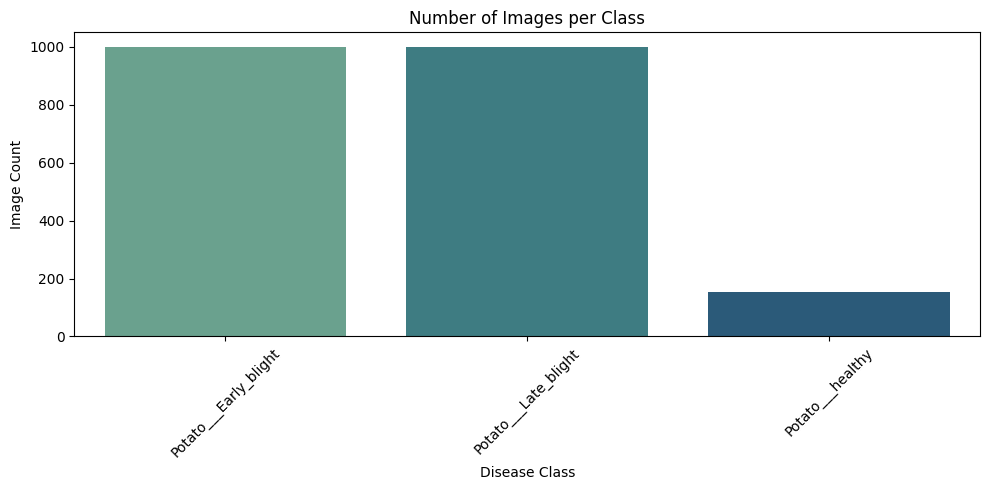

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    x=list(image_counts.keys()),
    y=list(image_counts.values()),
    hue=list(image_counts.keys()),
    palette='crest',
    legend=False
)

plt.title("Number of Images per Class")
plt.xticks(rotation=45)
plt.ylabel("Image Count")
plt.xlabel("Disease Class")
plt.tight_layout()
plt.show()



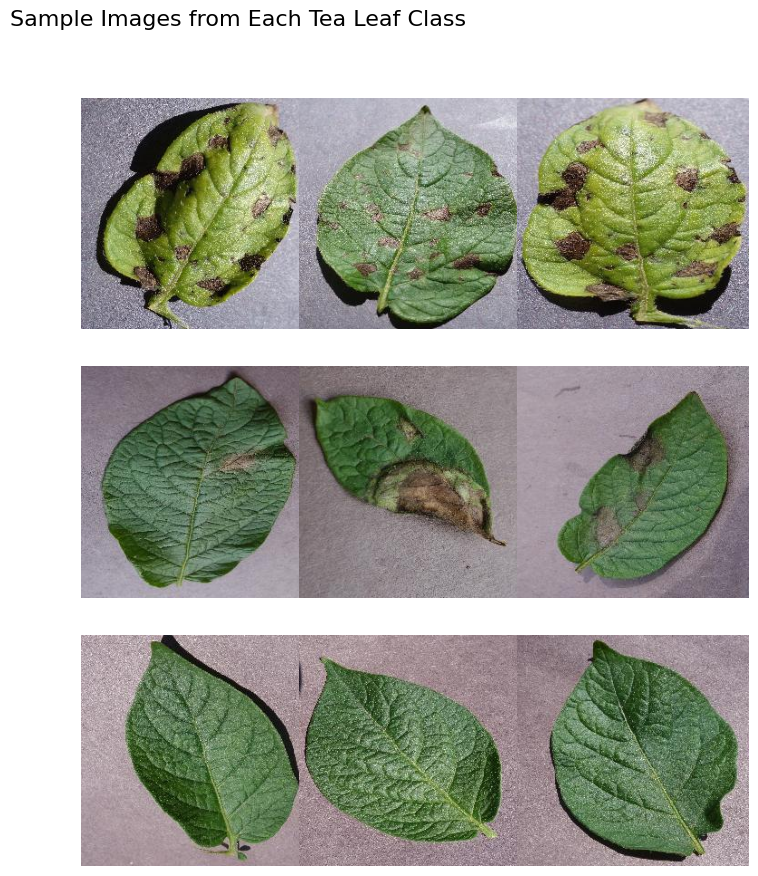

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_sample_images(dataset_dir, classes, samples_per_class=3, seed=42):
    import os, random
    import matplotlib.pyplot as plt
    from PIL import Image

    random.seed(seed)
    n_classes = len(classes)

    fig, axes = plt.subplots(
        n_classes,
        samples_per_class,
        figsize=(samples_per_class * 3.5, n_classes * 3)
    )

    if n_classes == 1:
        axes = [axes]

    for i, cls in enumerate(classes):
        cls_path = os.path.join(dataset_dir, cls)
        images = os.listdir(cls_path)

        sample_imgs = random.sample(
            images,
            min(samples_per_class, len(images))
        )

        for j in range(samples_per_class):
            ax = axes[i][j] if samples_per_class > 1 else axes[i]

            if j < len(sample_imgs):
                img = Image.open(os.path.join(cls_path, sample_imgs[j])).convert("RGB")
                ax.imshow(img)

            ax.axis("off")

            if j == 0:
                ax.set_ylabel(
                    cls,
                    fontsize=12,
                    rotation=0,
                    labelpad=40,
                    va="center"
                )

    plt.suptitle(
        "Sample Images from Each Tea Leaf Class",
        fontsize=16
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.subplots_adjust(left=0.35)
    plt.show()

dataset_dir = image_datasets['train'].root
classes = image_datasets['train'].classes

plot_sample_images(
    dataset_dir,
    classes,
    samples_per_class=3
)


In [9]:
# Load the pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)

# Freeze all layers except the final classification layer
for name, param in model.named_parameters():
    if "fc" in name:  # Unfreeze the final classification layer
        param.requires_grad = True
    else:
        param.requires_grad = False

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)  # Use all parameters


# Move the model to the GPU if available
device = torch.device("mps")
model = model.to(device)

/Users/adnanhaider/PycharmProjects/ResNetClassification/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adnanhaider/PycharmProjects/ResNetClassification/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
# Training loop
num_epochs = 2
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.float() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')


print("Training complete!")

train Loss: 0.0157 Acc: 0.0000
train Loss: 0.0324 Acc: 0.0000
train Loss: 0.0482 Acc: 0.0000
train Loss: 0.0628 Acc: 0.0000
train Loss: 0.0749 Acc: 0.0000
train Loss: 0.0862 Acc: 0.0000
train Loss: 0.0982 Acc: 0.0000
train Loss: 0.1066 Acc: 0.0005
train Loss: 0.1123 Acc: 0.0014
train Loss: 0.1176 Acc: 0.0019
train Loss: 0.1231 Acc: 0.0028
train Loss: 0.1256 Acc: 0.0037
train Loss: 0.1281 Acc: 0.0051
train Loss: 0.1321 Acc: 0.0056
train Loss: 0.1330 Acc: 0.0070
train Loss: 0.1359 Acc: 0.0074
train Loss: 0.1389 Acc: 0.0074
train Loss: 0.1443 Acc: 0.0088
train Loss: 0.1450 Acc: 0.0107
train Loss: 0.1470 Acc: 0.0112
train Loss: 0.1552 Acc: 0.0116
train Loss: 0.1643 Acc: 0.0125
train Loss: 0.1663 Acc: 0.0130
train Loss: 0.1738 Acc: 0.0135
train Loss: 0.1754 Acc: 0.0139
train Loss: 0.1776 Acc: 0.0144
train Loss: 0.1782 Acc: 0.0163
train Loss: 0.1799 Acc: 0.0172
train Loss: 0.1802 Acc: 0.0191
train Loss: 0.1811 Acc: 0.0204
train Loss: 0.1838 Acc: 0.0214
train Loss: 0.1895 Acc: 0.0228
train Lo

In [11]:
# Save the model
torch.save(model.state_dict(), 'potato_classification_model.pth')

In [14]:
import torch
from torchvision import models, transforms
from PIL import Image

# Load the saved model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1000)  # Adjust to match the original model's output units
model.load_state_dict(torch.load('potato_classification_model.pth'))
model.eval()

# Create a new model with the correct final layer
new_model = models.resnet18(pretrained=True)
new_model.fc = nn.Linear(new_model.fc.in_features, 2)  # Adjust to match the desired output units

# Copy the weights and biases from the loaded model to the new model
new_model.fc.weight.data = model.fc.weight.data[0:2]  # Copy only the first 2 output units
new_model.fc.bias.data = model.fc.bias.data[0:2]

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

class Evaluator:
    def __init__(self, model, dataloader, device, class_names=None):
        self.model = model
        self.dataloader = dataloader
        self.device = device
        self.class_names = class_names  # Optional list of class labels

    def evaluate(self):
        self.model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in self.dataloader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(inputs)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Compute metrics
        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1 Score:  {f1:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names if self.class_names else None,
                    yticklabels=self.class_names if self.class_names else None)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

        return {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1_score": f1,
            "confusion_matrix": cm
        }

Accuracy:  0.9665
Precision: 0.9676
Recall:    0.9665
F1 Score:  0.9668


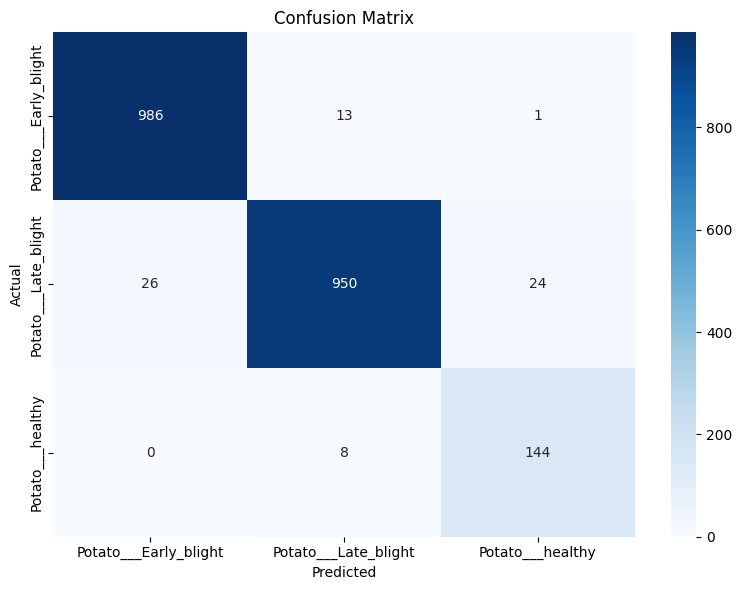

In [16]:
#device = torch.device("mps")

model = model.to(device)
model.eval()

class_names = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy'
]

evaluator = Evaluator(model, dataloaders['val'], device, class_names=class_names)
metrics = evaluator.evaluate()


In [17]:
# Load and preprocess the unseen image
image_path = './potatoData/image.jpg'  # Replace with the path to your image
image = Image.open(image_path)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)  # Add a batch dimension

In [18]:
# Select device (Apple Silicon M1/M2 or CPU)
device = torch.device("mps")

# Move model to device
model = model.to(device)
model.eval()

# Move input to device
input_batch = input_batch.to(device)

# Perform inference
with torch.no_grad():
    output = model(input_batch)

# Get the predicted class
_, predicted_class = output.max(1)

# Map the predicted class to the class name
class_names = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy'
]

predicted_class_name = class_names[predicted_class.item()]

print(f'The predicted class is: {predicted_class_name}')

The predicted class is: Potato___Late_blight


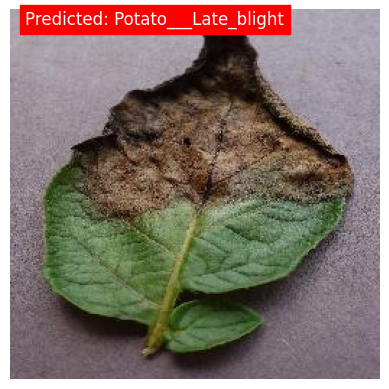

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Display the image with the predicted class name
image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.text(10, 10, f'Predicted: {predicted_class_name}', fontsize=12, color='white', backgroundcolor='red')
plt.show()